In [5]:
import numpy as np
import matplotlib.pyplot as plt

Создать класс Source со следующими параметрами:
Y = 10000 фотонов/МэВ

Разработать метод, разыгрывающий начальные направления фотонов для события с энергией E. При описании излучения света использовать следующие допущения:
- свет излучается изотропно
- выход фотонов линеен по энергии с коэффициентом пропорциональности Y

In [6]:
class Source:
    def __init__(self, pos: np.array):
        """
        Parameters
        ----------
        pos : np.array
            координаты источника
        """
        self.Y = 10000 
        self.pos = pos

    def sphere(self, R: float) -> np.array: #взял метод из ROOT
        r2 = 1.0

        while r2 > 0.25:
            a = np.random.random() - 0.5
            b = np.random.random() - 0.5
            r2 = a**2 + b**2

        z = R * (-1.0 + 8.0 * r2)
        scale = 8.0 * R * np.sqrt(0.25 - r2)

        x = a * scale
        y = b * scale

        point = np.array([x, y, z])

        return point

    def generate_photons(self, E: float) -> np.array:
        photon_number = int(E * self.Y)
        photons = np.zeros((photon_number, 3))
        for i in range(photon_number):
            photons[i] = self.sphere(1.0)
        return photons


In [7]:
source = Source(np.array([0, 0, 0]))
energies = [0.1, 0.3, 0.5, 1.0]
for energy in energies:
    photons = source.generate_photons(energy)
    print(f'Number of photons with energy {energy} MeV : {len(photons)}')

Number of photons with energy 0.1 MeV : 1000
Number of photons with energy 0.3 MeV : 3000
Number of photons with energy 0.5 MeV : 5000
Number of photons with energy 1.0 MeV : 10000


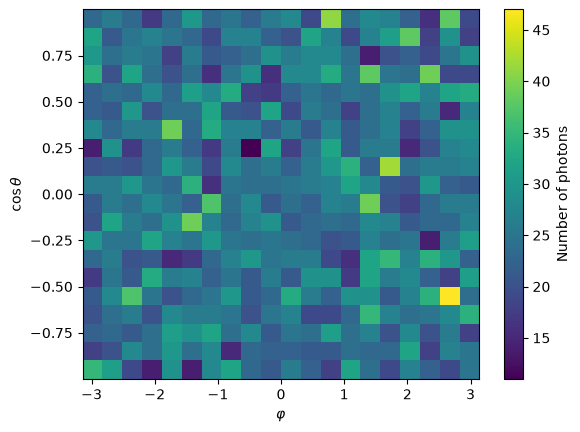

In [ ]:
phi = np.arctan2(photons[:, 1], photons[:, 0])
cos_theta = photons[:, 2]

plt.hist2d(phi, cos_theta, bins=10)
plt.xlabel(r"$\varphi$")
plt.ylabel(r"$\cos\theta$")
plt.colorbar(label="Number of photons")
plt.show()